In [ ]:
# import tensorflow as tf
# print(tf.__version__)

2.20.0


In [ ]:
# SYSTEM MEMORY CHECK
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

Total RAM: 230.05 GB
Available RAM: 226.93 GB


In [ ]:
# # INSTALL REQUIREMENTS
# !pip install opencv-python
# !pip install tensorflow
# !pip install openpyxl

In [ ]:
# import cv2
# print("OpenCV is already installed ")
# print("Version:", cv2.__version__)

In [ ]:
# IMPORTS

import os
import numpy as np
import pandas as pd
import random
import cv2
import tensorflow as tf

# ENABLE GPU MEMORY GROWTH (prevents hard allocation crash)
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16') #to reduce useof GPU memory
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GRU, Dense, Dropout, TimeDistributed, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [ ]:
# GLOBAL CONSTANTS

NUM_FRAMES = 120
MIN_FRAMES = 120
max_frames = 120
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224

In [ ]:
# GOOGLE DRIVE SETUP
from google.colab import drive
drive.mount('drive')

Mounted at drive


In [ ]:
# LOAD PREPROCESSED DATA 120 FRAMES FROM MY DRIVE

data_path = 'drive/My Drive/preprocessed_120_frames in numpy_array/'

print("Loading compressed data...")

X_npz = np.load(os.path.join(data_path, 'X_prep_120_frames.npz'))
X_key = list(X_npz.keys())[0]
X = X_npz[X_key]

y = np.load(os.path.join(data_path, 'y_labels_120_frames.npy'))

print("Shape of X after loading:", X.shape)
print("Shape of y after loading:", y.shape)

Loading compressed data...
Shape of X after loading: (1351, 120, 224, 224, 3)
Shape of y after loading: (1351,)


In [ ]:
print("Features (X) shape:", X.shape)
print("Labels (y) shape:", y.shape)

Features (X) shape: (1351, 120, 224, 224, 3)
Labels (y) shape: (1351,)


In [ ]:
# SEEDING
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
from tensorflow.keras.utils import to_categorical

# TRAIN-VALIDATION SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=SEED
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (945, 120, 224, 224, 3)
X_val shape: (406, 120, 224, 224, 3)


In [ ]:
# FREE MEMORY
del X, y
import gc
gc.collect()


0

In [ ]:
# ONE-HOT ENCODING
num_classes = 2
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_val_oh   = to_categorical(y_val, num_classes=num_classes)

In [ ]:
# FEATURE EXTRACTION
base_model = Xception(
    weights="imagenet",
    include_top=False,
    pooling='avg',
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# MODEL DEFINITION
from tensorflow.keras.layers import Input

input_layer = Input(shape=(NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH, 3))

# CNN applied per frame
x_ception_td = TimeDistributed(feature_extractor)(input_layer)

In [ ]:
# GRU STACK
gru_1 = GRU(512, return_sequences=True)(x_ception_td)
dropout_1 = Dropout(0.5)(gru_1)

gru_2 = GRU(256)(dropout_1)
dropout_2 = Dropout(0.5)(gru_2)

# Dense layers
dense_1 = Dense(128, activation="relu")(dropout_2)
dropout_3 = Dropout(0.5)(dense_1)

# OUTPUT LAYER
output_layer = Dense(num_classes, activation="sigmoid", dtype='float32')(dropout_3)

# Build model
model = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
# COMPILE
optimizer = Nadam(learning_rate=1e-4)

model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 224, 224,  │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 120, 2048)      │    20,861,480 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 120, 512)       │     3,935,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 256)            │       591,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,421,226 (96.97 MB)

 Trainable params: 25,366,698 (96.77 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
# =========================
# EARLY STOPPING
# =========================
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
# =========================
# CLASS WEIGHTS
# =========================
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
w0, w1 = class_weights

In [ ]:
# CHUNKED TRAINING

NUM_CHUNKS = 15 #10

X_train_chunks = np.array_split(X_train, NUM_CHUNKS)
y_train_chunks = np.array_split(y_train_oh, NUM_CHUNKS)

print(f"Training data split into {NUM_CHUNKS} chunks.")

all_history = []

Training data split into 15 chunks.


In [ ]:
# TRAINING LOOP
for i, (X_chunk, y_chunk) in enumerate(zip(X_train_chunks, y_train_chunks)):
    print(f"\nTraining chunk {i+1}/{NUM_CHUNKS}")

    history_chunk = model.fit(
        X_chunk,
        y_chunk,
        epochs=10,
        batch_size=1,
        class_weight={0: w0, 1: w1},
        callbacks=[early_stopping],
        validation_data=(X_val, y_val_oh),
        verbose=1
    )

    all_history.append(history_chunk.history)

    # cleanup
    del X_chunk, y_chunk
    gc.collect()



Training chunk 1/15
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1344s 7s/step - accuracy: 0.4603 - loss: 0.7172 - val_accuracy: 0.4483 - val_loss: 0.7399
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 292s 5s/step - accuracy: 0.4603 - loss: 0.6931 - val_accuracy: 0.4433 - val_loss: 0.7449
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 292s 5s/step - accuracy: 0.5079 - loss: 0.6934 - val_accuracy: 0.4360 - val_loss: 0.7387
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 294s 5s/step - accuracy: 0.5714 - loss: 0.6931 - val_accuracy: 0.4335 - val_loss: 0.7434
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 283s 5s/step - accuracy: 0.5873 - loss: 0.6625 - val_accuracy: 0.5517 - val_loss: nan
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 284s 5s/step - accuracy: 0.5238 - loss: 0.6914 - val_accuracy: 0.5714 - val_loss: nan
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 288s 5s/step - accuracy: 0.5556 - loss: 0.7590 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 289s 5s/step - accuracy: 0.5397 - loss: 0.6911 - val_accu

In [ ]:
# MERGE HISTORY
history = {
    "accuracy": [],
    "val_accuracy": [],
    "loss": [],
    "val_loss": []
}

for h in all_history:
    history["accuracy"] += h.get("accuracy", [])
    history["val_accuracy"] += h.get("val_accuracy", [])
    history["loss"] += h.get("loss", [])
    history["val_loss"] += h.get("val_loss", [])


In [ ]:
# MODEL EVALUATION
loss, accuracy = model.evaluate(X_val, y_val_oh)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.5665 - loss: 0.6717
Validation Loss: 0.6717
Validation Accuracy: 0.5665


13/13 ━━━━━━━━━━━━━━━━━━━━ 220s 10s/step
Confusion Matrix:
 [[ 27 176]
 [  0 203]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.13      0.23       203
           1       0.54      1.00      0.70       203

    accuracy                           0.57       406
   macro avg       0.77      0.57      0.47       406
weighted avg       0.77      0.57      0.47       406



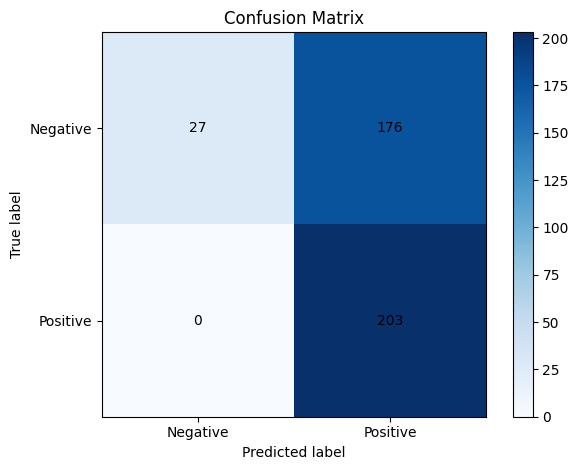

In [ ]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val_oh, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred))

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')

ticks = np.arange(2)
plt.xticks(ticks, ['Negative','Positive'])
plt.yticks(ticks, ['Negative','Positive'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.savefig("confusion_matrix_100_frames.png", dpi=300, bbox_inches='tight')
plt.show()

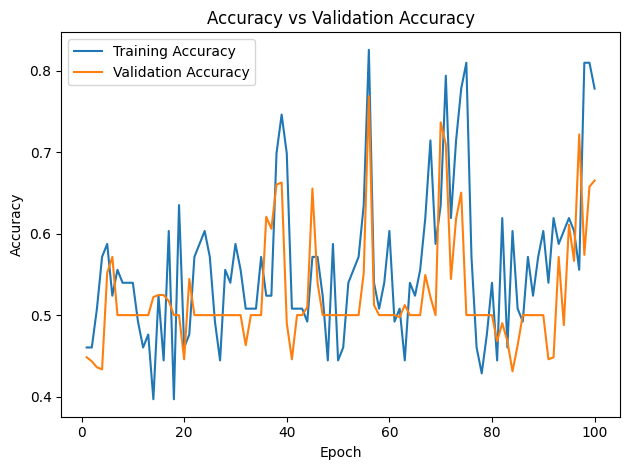

In [ ]:
# ACCURACY PLOT
accuracy = history['accuracy']
val_accuracy = history['val_accuracy']
epochs = range(1, len(accuracy) + 1)

plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_plot_120_frames.png", dpi=300, bbox_inches='tight')
plt.show()

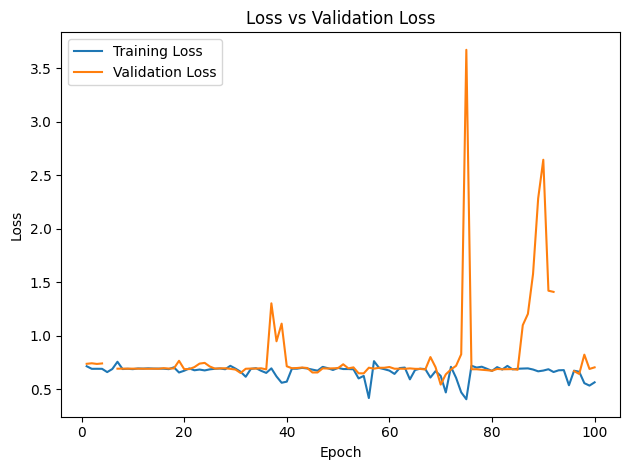

In [ ]:
# LOSS PLOT
loss = history['loss']
val_loss = history['val_loss']

plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig("loss_plot_120_frames.png", dpi=300, bbox_inches='tight')
plt.show()

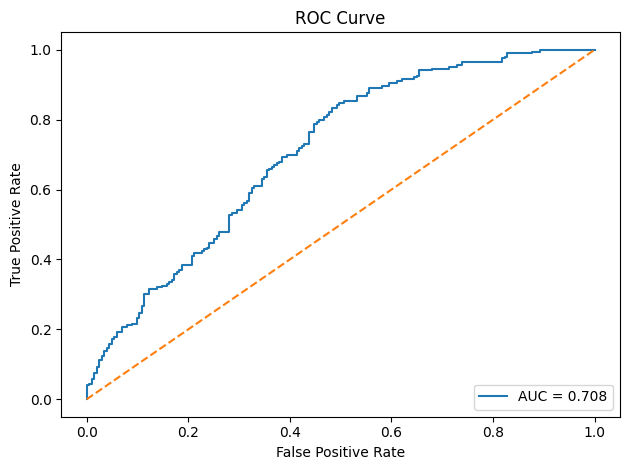

In [ ]:
# ROC CURVE + AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Use probability of positive class
y_scores = y_pred_prob[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

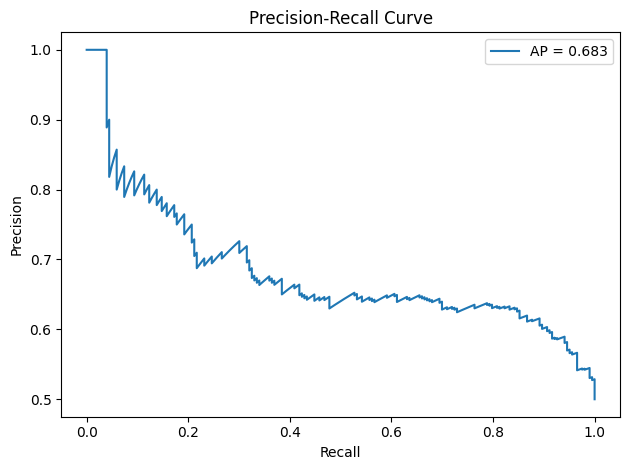

In [ ]:
# PRECISION-RECALL CURVE
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc = average_precision_score(y_true, y_scores)

plt.figure()
plt.plot(recall, precision, label=f'AP = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# RESULTS TABLE (CLEAN)
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results_table = pd.DataFrame({
    "Frames": [NUM_FRAMES],
    "Accuracy": [accuracy_score(y_true, y_pred)],
    "Precision": [precision_score(y_true, y_pred)],
    "Recall": [recall_score(y_true, y_pred)],
    "F1 Score": [f1_score(y_true, y_pred)],
    "ROC AUC": [roc_auc],
    "PR AUC": [pr_auc]
})

print(f"\nExperiment Results Table ({NUM_FRAMES} Frames):")
display(results_table)


Experiment Results Table (120 Frames):


,Frames,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,120,0.566502,0.53562,1.0,0.697595,0.708413,0.682943


In [ ]:
# RESULTS TABLE
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results_table = pd.DataFrame({
    "Segments": [NUM_FRAMES],
    "Accuracy": [accuracy_score(y_true, y_pred)],
    "Precision": [precision_score(y_true, y_pred)],
    "Recall": [recall_score(y_true, y_pred)],
    "F1 Score": [f1_score(y_true, y_pred)],
    "ROC AUC": [roc_auc],
    #"PR AUC": [pr_auc]
})

print(f"\nExperiment Results Table ({NUM_FRAMES} Frames):")
display(results_table)


Experiment Results Table (120 Frames):


,Segments,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,120,0.566502,0.53562,1.0,0.697595,0.708413


In [ ]:
# SAVE MODEL
model.save("Xception_model_seq_120_frames.keras")
model.save("Xception_model_seq_120_frames.h5")
model.save_weights("Xception_model_seq_120_frames.weights.h5")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
#copy  saved models to this folder preprocessed_120_frames in numpy_array


In [ ]:
!cp /content/Xception_model_seq_120_frames.h5 "/content/drive/MyDrive/preprocessed_120_frames in numpy_array/"

In [ ]:
#copy  saved models to this folder preprocessed_120_frames in numpy_array


In [ ]:
!cp /content/Xception_model_seq_120_frames.keras "/content/drive/MyDrive/preprocessed_120_frames in numpy_array/"

In [ ]:
!cp /content/Xception_model_seq_120_frames.weights.h5 "/content/drive/MyDrive/preprocessed_120_frames in numpy_array/"

In [ ]:
#cjheck contents in the folder containing weights
!ls "/content/drive/MyDrive/preprocessed_120_frames in numpy_array/"

prep_120_v1.ipynb		     Xception_model_seq_120_frames.weights.h5
prep_120_v2.ipynb		     X_prep_120_frames.npz
Xception_model_seq_120_frames.h5     y_labels_120_frames.npy
Xception_model_seq_120_frames.keras
